# HMDA 2024 Responsible ML Capstone

## 1. Responsible ML Framing

This notebook studies a binary prediction task using HMDA 2024 loan application data: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is intended to support loan approval decisions, so the system context is not purely technical; these decisions affect access to credit and can create meaningful financial and social consequences.

**Stakeholders:** loan applicants, financial institutions, and regulators.

**Conflicting interests:** lenders want efficient and accurate decisions with controlled risk, applicants want fair access to credit and protection from unjust denial, and regulators want compliance, transparency, and non-discrimination.

**Risk vs benefit:** a useful model can improve consistency and provide a reproducible benchmark for approval decisions, but a poor model can deny credit unfairly, amplify disparities across groups, and create regulatory or reputational harm.

**Failure definition:** failure means more than low predictive quality. It also includes unfair subgroup behavior, excessive harmful errors, or a decision process that benefits institutions while disproportionately harming applicants.

**What are we optimizing?** This notebook does not optimize for accuracy alone. The objective is to balance predictive performance, with `AUC` as a core metric, against fairness across demographic groups.

**Who benefits vs who is harmed?** A better model may help institutions make more consistent decisions and may benefit applicants if errors and disparities are reduced. A worse model can especially harm applicants who are wrongly denied and can expose institutions to fairness and compliance risk.

## Data Requirement Note

Place `2024_lar.zip` in the project root before running this notebook. The notebook assumes local file access and does not download the raw HMDA archive automatically.

## 2. Environment and Imports

This section imports the libraries used in the notebook and defines the paths for the raw HMDA archive, extracted text file, and filtered parquet dataset.

In [1]:
# If you run this notebook in Google Colab, uncomment the next line first.
# !pip install duckdb pyarrow pandas numpy scikit-learn xgboost matplotlib scipy

from pathlib import Path
from zipfile import ZipFile

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Define the core project paths used throughout the notebook.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = PROJECT_ROOT / "2024_lar.zip"
TXT_PATH = PROJECT_ROOT / "2024_lar.txt"
PARQUET_PATH = DATA_DIR / "hmda_filtered.parquet"
RAW_MEMBER_NAME = "2024_lar.txt"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# Extract the raw text file only when it is missing locally.
if not TXT_PATH.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError("Expected either 2024_lar.txt or 2024_lar.zip in the project root.")
    print("Extracting 2024_lar.txt from the zip archive. This can take a while on the first run...")
    with ZipFile(ZIP_PATH) as zf:
        zf.extract(RAW_MEMBER_NAME, path=PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw HMDA text file: {TXT_PATH}")
print(f"Filtered parquet output: {PARQUET_PATH}")


Project root: /Users/hsuan/Documents/responsible_ML/Capstone
Raw HMDA text file: /Users/hsuan/Documents/responsible_ML/Capstone/2024_lar.txt
Filtered parquet output: /Users/hsuan/Documents/responsible_ML/Capstone/data/hmda_filtered.parquet


## 3. Data Source and Problem Framing

This notebook uses the 2024 HMDA Loan/Application Register data. The prediction task is binary classification: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is meant to support approval decisions, not to predict default risk or later loan performance.

Reference pages:
- [HMDA 2024 dynamic national loan-level dataset](https://ffiec.cfpb.gov/data-publication/dynamic-national-loan-level-dataset/2024)
- [HMDA loan/application register data fields documentation](https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields)

## 4. Raw Data Inspection with DuckDB

DuckDB is used to inspect the raw pipe-delimited HMDA file before filtering so the notebook works from the actual schema and field names.

In [2]:
# Escape local paths so they are safe inside DuckDB SQL strings.
def sql_path(path: Path) -> str:
    return path.as_posix().replace("'", "''")

# Open DuckDB for schema preview and parquet export.
con = duckdb.connect()

# Preview the raw HMDA schema before creating the filtered dataset.
schema_preview = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_csv_auto(
        '{sql_path(TXT_PATH)}',
        delim='|',
        header=True,
        sample_size=20000
    )
    """
).df()

display(schema_preview.head(25))
print(f"Total number of columns in the raw HMDA file: {len(schema_preview)}")


,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
5,census_tract,VARCHAR,YES,None,None,None
6,conforming_loan_limit,VARCHAR,YES,None,None,None
7,derived_loan_product_type,VARCHAR,YES,None,None,None
8,derived_dwelling_category,VARCHAR,YES,None,None,None
9,derived_ethnicity,VARCHAR,YES,None,None,None


Total number of columns in the raw HMDA file: 99


## 5. Filter and Export a Smaller Dataset

This step keeps only the rows and columns needed for the modeling workflow and saves the result as `data/hmda_filtered.parquet` for reuse.

In [3]:
# Keep only the columns needed for modeling and fairness analysis.
selected_columns = [
    "action_taken",
    "property_value",
    "income",
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "derived_race",
    "derived_sex",
    "derived_ethnicity",
]

selected_columns_sql = ",\n        ".join(selected_columns)

# Create the filtered parquet file with the current outcome and sex filters.
con.execute(
    f"""
    COPY (
        SELECT
            {selected_columns_sql}
        FROM read_csv_auto(
            '{sql_path(TXT_PATH)}',
            delim='|',
            header=True,
            all_varchar=True,
            sample_size=20000
        )
        WHERE action_taken IN ('1', '2', '3')
          AND derived_sex IN ('Male', 'Female')
    ) TO '{sql_path(PARQUET_PATH)}' (FORMAT PARQUET)
    """
)

# Record the size of the actual filtered modeling dataset.
filtered_schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).df()
filtered_row_count = con.execute(
    f"SELECT COUNT(*) AS row_count FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).fetchone()[0]
filtered_column_count = len(filtered_schema)

print(f"Filtered parquet written to: {PARQUET_PATH}")
print(f"Rows kept for modeling: {filtered_row_count:,}")
print(f"Total number of columns in the filtered dataset: {filtered_column_count}")
print(f"Total number of rows in the filtered dataset: {filtered_row_count:,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filtered parquet written to: /Users/hsuan/Documents/responsible_ML/Capstone/data/hmda_filtered.parquet
Rows kept for modeling: 4,886,502
Total number of columns in the filtered dataset: 15
Total number of rows in the filtered dataset: 4,886,502


## 6. Load the Filtered Data into pandas

The parquet file becomes the main analysis dataset for the rest of the notebook. This section loads it into pandas, previews a few rows, shows the dataset size, and exports a small CSV preview.

In [4]:
# Load the filtered parquet used for all remaining analysis steps.
df = pd.read_parquet(PARQUET_PATH)
preview_csv_path = DATA_DIR / "hmda_filtered_preview.csv"
preview_rows = 20

print("Parquet is the main dataset used for the remaining analysis steps in this notebook.")

# Record dataset size and export a tiny CSV preview for quick inspection.
dataset_size = pd.Series(
    {
        "rows": df.shape[0],
        "columns": df.shape[1],
    }
).to_frame("value")

print(f"Filtered dataframe shape: {df.shape}")
display(dataset_size)
display(df.head())
display(pd.Series(df.columns, name="column_name").to_frame())

preview_df = df.head(preview_rows).copy()
preview_df.to_csv(preview_csv_path, index=False)
print(f"Exported a {preview_rows}-row CSV preview to: {preview_csv_path}")

# Check missingness early because it affects preprocessing and subgroup coverage.
missing_summary = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

display(missing_summary.head(10))


Parquet is the main dataset used for the remaining analysis steps in this notebook.
Filtered dataframe shape: (4886502, 15)


,value
rows,4886502
columns,15


,action_taken,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,derived_race,derived_sex,derived_ethnicity
0,1,975000,0,5359,101900,62.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,31,1,3,White,Male,Hispanic or Latino
1,2,655000,140,5395,156200,117.0,NY,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Asian,Male,Not Hispanic or Latino
2,1,555000,138,7409,79400,57.0,FL,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino
3,2,725000,108,4295,133300,47.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino
4,1,515000,65,2902,156200,52.0,NY,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino


,column_name
0,action_taken
1,property_value
2,income
3,tract_population
4,ffiec_msa_md_median_family_income
5,tract_to_msa_income_percentage
6,state_code
7,derived_loan_product_type
8,derived_dwelling_category
9,loan_purpose


Exported a 20-row CSV preview to: /Users/hsuan/Documents/responsible_ML/Capstone/data/hmda_filtered_preview.csv


,missing_pct
action_taken,0.0
property_value,0.0
income,0.0
tract_population,0.0
ffiec_msa_md_median_family_income,0.0
tract_to_msa_income_percentage,0.0
state_code,0.0
derived_loan_product_type,0.0
derived_dwelling_category,0.0
loan_purpose,0.0


## 7. Label Creation

`action_taken` is converted into a binary target: approve (`1`, `2`) versus deny (`3`). This creates the label used for modeling.

In [5]:
label_map = {"1": 1, "2": 1, "3": 0}

# Map HMDA action outcomes into the binary target used throughout the notebook.
df["label"] = df["action_taken"].map(label_map)
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

# Show both counts and shares so the class imbalance is visible before modeling.
display(df[["action_taken", "label"]].head())
display(df["label"].value_counts().rename_axis("label").to_frame("count"))
display(df["label"].value_counts(normalize=True).rename_axis("label").to_frame("share").round(4))


,action_taken,label
0,1,1
1,2,1
2,1,1
3,2,1
4,1,1


,count
label,
1,3539072
0,1347430


,share
label,
1,0.7243
0,0.2757


## 8. Feature Selection

The model uses a compact set of numeric and categorical features, while `derived_race`, `derived_sex`, and `derived_ethnicity` are kept only for subgroup analysis and not used as training inputs.

In [6]:
# Keep protected-group columns for later subgroup analysis.
fairness_group_columns = ["derived_race", "derived_sex", "derived_ethnicity"]

# Separate numeric and categorical inputs for preprocessing.
numeric_features = [
    "property_value",
    "income",
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
]

categorical_features = [
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
]

# Exclude protected attributes from training while keeping them for fairness checks.
model_features = numeric_features + categorical_features

required_columns = model_features + fairness_group_columns + ["label"]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

# Document the role each variable plays in the notebook.
feature_summary = pd.DataFrame(
    {
        "feature": numeric_features + categorical_features + fairness_group_columns,
        "role": (
            ["numeric feature"] * len(numeric_features)
            + ["categorical feature"] * len(categorical_features)
            + ["fairness grouping column"] * len(fairness_group_columns)
        ),
    }
)

display(feature_summary)


,feature,role
0,property_value,numeric feature
1,income,numeric feature
2,tract_population,numeric feature
3,ffiec_msa_md_median_family_income,numeric feature
4,tract_to_msa_income_percentage,numeric feature
5,state_code,categorical feature
6,derived_loan_product_type,categorical feature
7,derived_dwelling_category,categorical feature
8,loan_purpose,categorical feature
9,lien_status,categorical feature


## 9. Data Cleaning and Preprocessing

This section keeps the required columns, converts numeric-looking fields to numeric format, standardizes common missing-value tokens, and defines the numeric and categorical preprocessing pipeline.

In [7]:
# Restrict the modeling frame to the columns used in this notebook.
model_df = df[required_columns].copy()

# Normalize the common string tokens that HMDA uses for missing or exempt values.
missing_tokens = {"NA": np.nan, "Exempt": np.nan, "": np.nan}

# Coerce numeric features and clean categorical values before preprocessing.
for column in numeric_features:
    model_df[column] = pd.to_numeric(model_df[column].replace(missing_tokens), errors="coerce")

for column in categorical_features + fairness_group_columns:
    model_df[column] = model_df[column].replace(missing_tokens)

X = model_df[model_features]
y = model_df["label"]

# Use separate preprocessing branches for numeric and categorical features.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine both branches into one reusable preprocessing object.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

display(model_df[required_columns].head())


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,derived_race,derived_sex,derived_ethnicity,label
0,975000.0,0.0,5359,101900,62.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,31,1,3,White,Male,Hispanic or Latino,1
1,655000.0,140.0,5395,156200,117.0,NY,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Asian,Male,Not Hispanic or Latino,1
2,555000.0,138.0,7409,79400,57.0,FL,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino,1
3,725000.0,108.0,4295,133300,47.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino,1
4,515000.0,65.0,2902,156200,52.0,NY,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,White,Male,Hispanic or Latino,1


## 10. Train and Test Split

The data is split into training and test sets with `random_state=42` and stratification on the label so the approval-denial balance stays stable across both splits.

In [8]:
# Use a stratified split so the approval rate stays stable across train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Record split sizes and positive-class rates for transparency.
split_summary = pd.Series(
    {
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "train_positive_rate": y_train.mean(),
        "test_positive_rate": y_test.mean(),
    }
).to_frame("value")

display(split_summary.round(4))


,value
train_rows,3.909201e+06
test_rows,9.773010e+05
train_positive_rate,7.243000e-01
test_positive_rate,7.243000e-01


## 11. Baseline Model

This section fits `LogisticRegression(max_iter=1000)` as the baseline model.

In [9]:
# Fit logistic regression as the interpretable baseline model.
baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## 12. Evaluation

This section reports a compact baseline summary using `accuracy`, `AUC`, `log-loss`, `precision`, `recall`, and a small `FPR` table.

In [10]:
# Keep evaluation logic in one helper so every model is scored the same way.
def evaluate_model(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_score),
        "log_loss": log_loss(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "fpr": fpr,
        "fnr": fnr,
    }


# Generate baseline predictions on the held-out test split.
y_pred_baseline = baseline_pipeline.predict(X_test)
y_score_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_score_baseline)

# Report the main baseline metrics in compact tables.
baseline_performance_metrics = pd.Series(
    {
        key: baseline_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

baseline_error_metrics = pd.Series(
    {
        "overall_fpr": baseline_metrics["fpr"],
        "overall_fnr": baseline_metrics["fnr"],
    }
).round(4).to_frame("value")

display(baseline_performance_metrics)
display(baseline_error_metrics)


,value
accuracy,0.7388
auc,0.7374
log_loss,0.5177
precision,0.7569
recall,0.9420


,value
overall_fpr,0.7948
overall_fnr,0.0580


This subgroup evaluation is included as an early diagnostic view of baseline model behavior across groups. At this stage, it is not a formal fairness assessment and should not be treated as a final fairness conclusion.

## 13. Main Model: XGBoost

This section fits `XGBClassifier(random_state=42)` as the main model and reports the same compact evaluation metrics used for the logistic regression baseline.

In [11]:
# Build the main XGBoost pipeline with the same preprocessing as the baseline.
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Fit XGBoost as the main model used in the rest of the notebook.
xgb_pipeline.fit(X_train, y_train)

display(xgb_pipeline)

# Score the held-out test split with the XGBoost model.
y_pred_xgb = xgb_pipeline.predict(X_test)
y_score_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_metrics = evaluate_model(y_test, y_pred_xgb, y_score_xgb)

xgb_performance_metrics = pd.Series(
    {
        key: xgb_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

xgb_error_metrics = pd.Series(
    {
        "overall_fpr": xgb_metrics["fpr"],
        "overall_fnr": xgb_metrics["fnr"],
    }
).round(4).to_frame("value")

display(xgb_performance_metrics)
display(xgb_error_metrics)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

,value
accuracy,0.7819
auc,0.7977
log_loss,0.4654
precision,0.7993
recall,0.9331


,value
overall_fpr,0.6154
overall_fnr,0.0669


## 14. Second Model: Random Forest

This section fits `RandomForestClassifier(random_state=42)` as a second comparison model. It reuses the existing train/test split and preprocessing output, then reports the same compact evaluation metrics and a three-model comparison table.

In [12]:
# Reuse the fitted preprocessing step so the random-forest comparison uses the same representation.
rf_preprocessor = xgb_pipeline.named_steps["preprocess"]
X_train_rf = rf_preprocessor.transform(X_train)
X_test_rf = rf_preprocessor.transform(X_test)

# Keep the random forest light enough to remain practical on the full HMDA training set.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=25,
    max_features="sqrt",
    max_samples=0.1,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)

# Score the same held-out test split for side-by-side comparison.
y_pred_rf = rf_model.predict(X_test_rf)
y_score_rf = rf_model.predict_proba(X_test_rf)[:, 1]
rf_metrics = evaluate_model(y_test, y_pred_rf, y_score_rf)

rf_performance_metrics = pd.Series(
    {
        key: rf_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

rf_error_metrics = pd.Series(
    {
        "overall_fpr": rf_metrics["fpr"],
        "overall_fnr": rf_metrics["fnr"],
    }
).round(4).to_frame("value")

display(rf_performance_metrics)
display(rf_error_metrics)

# Collect all model metrics in one comparison table.
comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": baseline_performance_metrics.loc["accuracy", "value"],
            "auc": baseline_performance_metrics.loc["auc", "value"],
            "log_loss": baseline_performance_metrics.loc["log_loss", "value"],
            "precision": baseline_performance_metrics.loc["precision", "value"],
            "recall": baseline_performance_metrics.loc["recall", "value"],
            "fpr": baseline_error_metrics.loc["overall_fpr", "value"],
            "fnr": baseline_error_metrics.loc["overall_fnr", "value"],
        },
        {
            "model": "XGBoost",
            "accuracy": xgb_performance_metrics.loc["accuracy", "value"],
            "auc": xgb_performance_metrics.loc["auc", "value"],
            "log_loss": xgb_performance_metrics.loc["log_loss", "value"],
            "precision": xgb_performance_metrics.loc["precision", "value"],
            "recall": xgb_performance_metrics.loc["recall", "value"],
            "fpr": xgb_error_metrics.loc["overall_fpr", "value"],
            "fnr": xgb_error_metrics.loc["overall_fnr", "value"],
        },
        {
            "model": "Random Forest",
            "accuracy": rf_performance_metrics.loc["accuracy", "value"],
            "auc": rf_performance_metrics.loc["auc", "value"],
            "log_loss": rf_performance_metrics.loc["log_loss", "value"],
            "precision": rf_performance_metrics.loc["precision", "value"],
            "recall": rf_performance_metrics.loc["recall", "value"],
            "fpr": rf_error_metrics.loc["overall_fpr", "value"],
            "fnr": rf_error_metrics.loc["overall_fnr", "value"],
        },
    ]
).set_index("model").round(4)

display(comparison_df)


,value
accuracy,0.7647
auc,0.7786
log_loss,0.4874
precision,0.7691
recall,0.9647


,value
overall_fpr,0.7605
overall_fnr,0.0353


,accuracy,auc,log_loss,precision,recall,fpr,fnr
model,,,,,,,
Logistic Regression,0.7388,0.7374,0.5177,0.7569,0.9420,0.7948,0.0580
XGBoost,0.7819,0.7977,0.4654,0.7993,0.9331,0.6154,0.0669
Random Forest,0.7647,0.7786,0.4874,0.7691,0.9647,0.7605,0.0353


## 15. Lecture 02: Explainability Analysis

### SHAP global

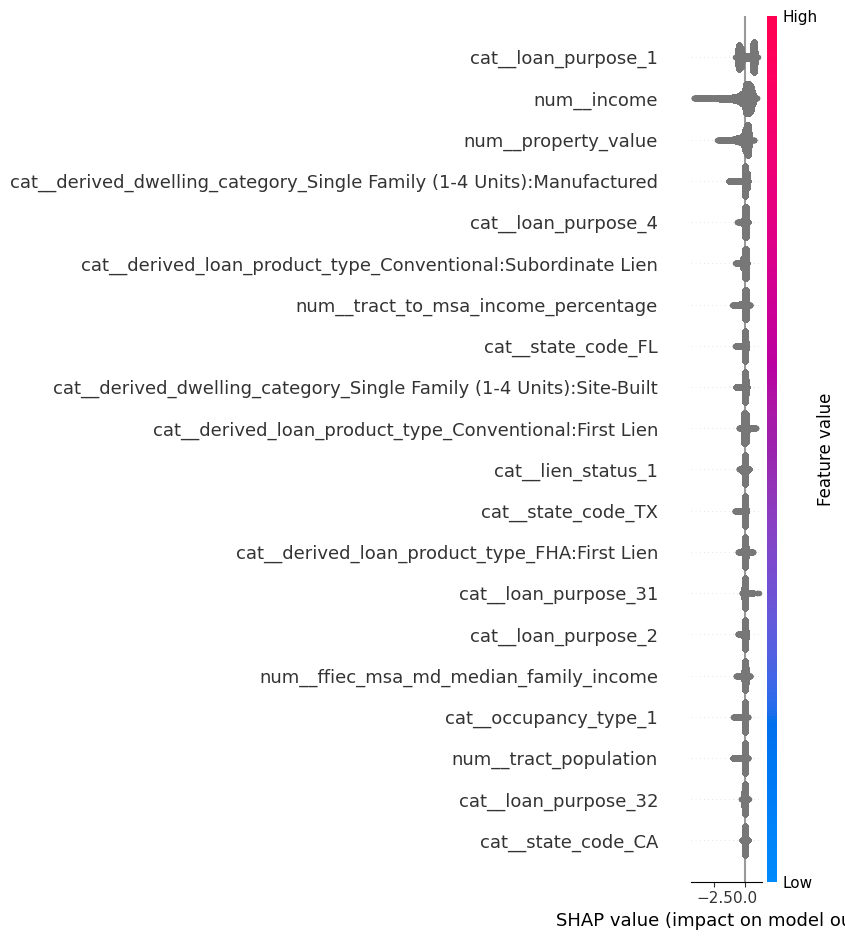

In [13]:
# If you run this notebook in Google Colab, uncomment the next line first.
# !pip install shap

import shap

# Flag tract-level features that may act as demographic proxies.
PROXY_FEATURES = [
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
]

# Transform the test set and recover the expanded feature names used by the model.
X_test_transformed = xgb_pipeline.named_steps["preprocess"].transform(X_test)
feature_names = xgb_pipeline.named_steps["preprocess"].get_feature_names_out()

# Build a SHAP explainer for the trained XGBoost classifier.
explainer = shap.TreeExplainer(xgb_pipeline.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

# Show the most influential features across the test set.
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
)


The SHAP summary plot shows the most important features driving the model’s predictions across all applicants. The top feature is loan purpose, indicating that approval decisions vary significantly depending on the type of loan.

This is followed by income and property value, both of which have a strong influence on the model. Higher values of these features generally push predictions toward approval, while lower values push toward denial.

A notable observation is that tract_minority_population_percent and ffiec_msa_md_median_family_income appear among the important features. Since these are neighborhood-level variables, they may act as proxies for demographic characteristics such as race or socioeconomic status. This suggests that the model may be indirectly using geographic information when making decisions.

Overall, the model is primarily driven by financial variables, but the presence of tract-level features indicates a potential risk of indirect bias.

### Feature importance table

In [14]:
# Summarize global SHAP importance across the test set.
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Add ranks and flag tract-level variables that may proxy demographics.
shap_importance["rank"] = shap_importance.index + 1
shap_importance["proxy_risk"] = shap_importance["feature"].apply(
    lambda f: "Potential demographic proxy" if any(p in f for p in PROXY_FEATURES) else ""
)

print("=== Top 20 Features by Mean |SHAP| ===")
display(shap_importance[["rank", "feature", "mean_abs_shap", "proxy_risk"]].head(20))

print("\n=== Top 5 Features Driving Predictions ===")
display(shap_importance[["rank", "feature", "mean_abs_shap", "proxy_risk"]].head(5))


=== Top 20 Features by Mean |SHAP| ===


,rank,feature,mean_abs_shap,proxy_risk
0,1,cat__loan_purpose_1,0.541519,
1,2,num__income,0.366682,
2,3,num__property_value,0.210103,
3,4,cat__derived_dwelling_category_Single Family (...,0.115933,
4,5,cat__loan_purpose_4,0.074293,
5,6,cat__derived_loan_product_type_Conventional:Su...,0.072074,
6,7,num__tract_to_msa_income_percentage,0.068790,Potential demographic proxy
7,8,cat__state_code_FL,0.067371,
8,9,cat__derived_dwelling_category_Single Family (...,0.061603,
9,10,cat__derived_loan_product_type_Conventional:Fi...,0.060583,



=== Top 5 Features Driving Predictions ===


,rank,feature,mean_abs_shap,proxy_risk
0,1,cat__loan_purpose_1,0.541519,
1,2,num__income,0.366682,
2,3,num__property_value,0.210103,
3,4,cat__derived_dwelling_category_Single Family (...,0.115933,
4,5,cat__loan_purpose_4,0.074293,


The feature importance table confirms that loan purpose is the most influential variable in the model, followed by income and property value. This indicates that both the type of loan and the applicant’s financial capacity play a central role in determining approval outcomes.

Among the top features, tract_minority_population_percent appears as an important variable and is flagged as a potential demographic proxy. This is important because it reflects neighborhood-level characteristics rather than individual attributes, suggesting that the model may be indirectly incorporating demographic information.

Other important features include loan product type and dwelling category, which indicate that structural aspects of the loan also influence decisions, though to a lesser extent than financial variables.

Overall, the model is primarily driven by financial and loan-related features, but the presence of tract-level variables among the top predictors highlights a potential risk of indirect bias.

### Local explanation (waterfall)

,value
actual_label,0.000000
predicted_label,0.000000
approval_probability,0.499793


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type
2037709,3005000.0,887.0,4032,101900,0.0,NY,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,2,2,1


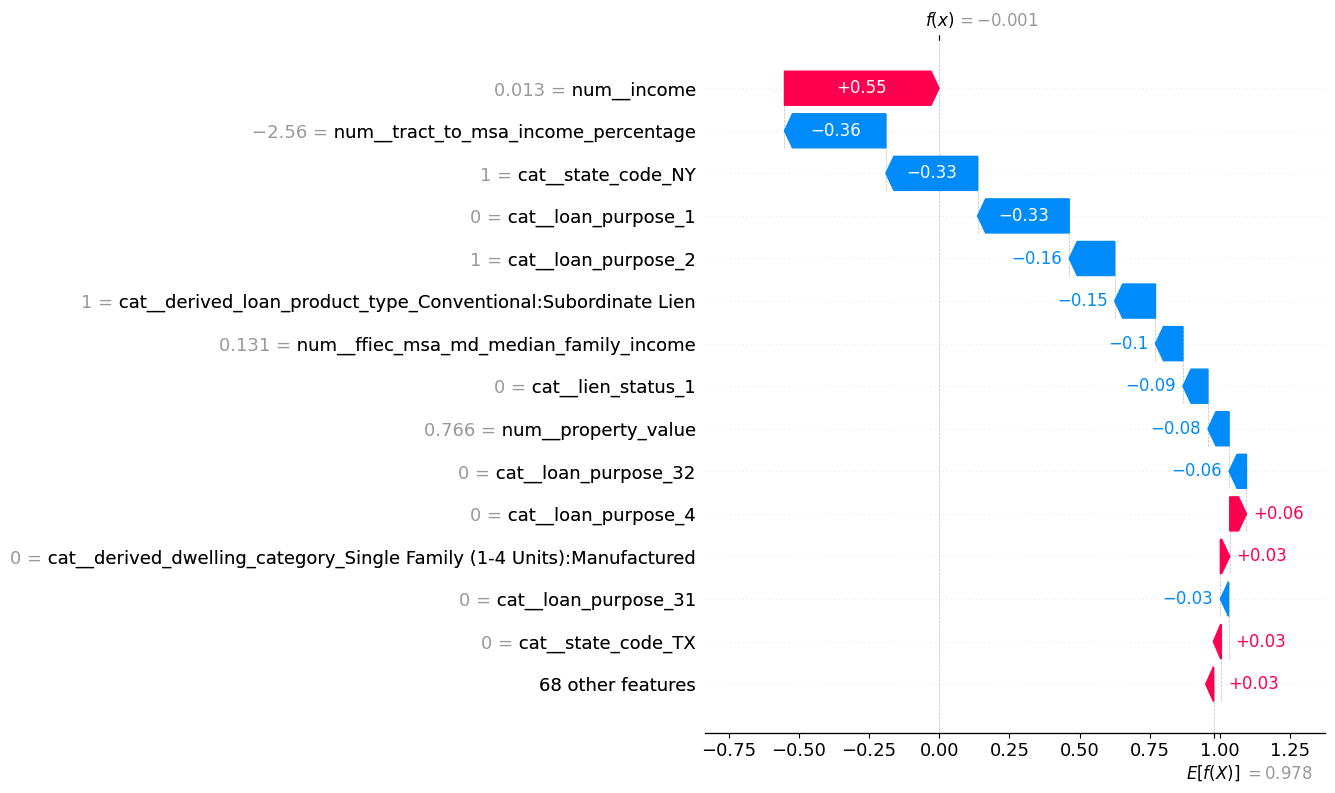

In [15]:
# Select a denied application that the model also predicts as denied.
denied_positions = np.where((y_test.values == 0) & (y_pred_xgb == 0))[0]
denied_idx = denied_positions[0]

# Summarize the selected case before plotting the local explanation.
denied_case_summary = pd.Series({
    "actual_label": y_test.iloc[denied_idx],
    "predicted_label": y_pred_xgb[denied_idx],
    "approval_probability": y_score_xgb[denied_idx],
}).to_frame("value")

display(denied_case_summary)
display(X_test.iloc[[denied_idx]])

# Build a SHAP explanation object for the single denied case.
single_explanation = shap.Explanation(
    values=shap_values[denied_idx],
    base_values=explainer.expected_value,
    data=(
        X_test_transformed[denied_idx].toarray().ravel()
        if hasattr(X_test_transformed[denied_idx], "toarray")
        else X_test_transformed[denied_idx]
    ),
    feature_names=feature_names,
)

# Plot the local feature contributions for this prediction.
shap.plots.waterfall(single_explanation, max_display=15)


The waterfall plot explains why this specific applicant was denied. The final prediction is strongly negative, indicating a low probability of approval.

The most influential factor is income, which has a large negative contribution and is the primary driver of the denial. This suggests that the applicant’s low income significantly reduces their chances of approval.

Other features such as loan purpose, lien status, and property value also contribute negatively, reinforcing the denial decision. In addition, tract_minority_population_percent appears with a negative contribution, indicating that a neighborhood-level variable also influences the individual prediction.

While a few features have small positive effects, they are not strong enough to offset the negative impact of income and other variables.

Overall, the decision is driven by the combined effect of multiple features, with income playing the dominant role.

### Counterfactual

In [16]:
# If you run this notebook in Google Colab, uncomment the next line first.
# !pip install dice-ml

import dice_ml
from dice_ml import Dice

# Restrict counterfactual changes to actionable applicant-level financial features.
ACTIONABLE_FEATURES = ["property_value", "income"]

# Keep only actionable features that still exist after feature-selection changes.
ACTIONABLE_FEATURES = [feature for feature in ACTIONABLE_FEATURES if feature in X_train.columns]
if not ACTIONABLE_FEATURES:
    raise ValueError("No actionable counterfactual features remain in the current feature set.")

# Build the DiCE training frame with the binary outcome.
train_for_dice = X_train.copy()
train_for_dice["action_taken_binary"] = y_train.values

# Register the data and fitted model for counterfactual generation.
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=ACTIONABLE_FEATURES,
    outcome_name="action_taken_binary",
)

dice_model_obj = dice_ml.Model(
    model=xgb_pipeline,
    backend="sklearn",
    model_type="classifier",
)

exp_dice = Dice(dice_data, dice_model_obj, method="random")

print("=== Counterfactual: What Would Flip This Denial? ===")
print(f"Approval probability: {y_score_xgb[denied_idx]:.3f}")
print(f"Varying only available actionable features: {', '.join(ACTIONABLE_FEATURES)}")

# Try to generate counterfactuals, but do not fail the notebook if none are found.
try:
    cf_result = exp_dice.generate_counterfactuals(
        X_test.iloc[[denied_idx]],
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=ACTIONABLE_FEATURES,
    )
    cf_result.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"Counterfactual generation was skipped: {e}")


=== Counterfactual: What Would Flip This Denial? ===
Approval probability: 0.500
Varying only available actionable features: property_value, income


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.94it/s]

100%|██████████| 1/1 [00:00<00:00,  1.94it/s]

Query instance (original outcome : 0)


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,action_taken_binary
0,3005000.0,887.0,4032,101900,0.0,NY,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,2,2,1,0



Diverse Counterfactual set (new outcome: 1)


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,action_taken_binary
0,-,-,-,-,-,-,-,-,-,-,-,1
1,-,86011452.0,-,-,-,-,-,-,-,-,-,1


The counterfactual analysis shows what changes would be required to flip the prediction from denial to approval. In this case, the model suggests that increasing income would lead to an approved outcome.

However, the required increases in income may be very large, which indicates that the model is highly sensitive to income and places significant weight on this feature when making decisions.

While the counterfactual identifies the direction of change, the magnitude of the suggested changes may not always be practical. This limits the usefulness of the model in providing actionable guidance to applicants.

## 16. Lecture 03: Formal Fairness Analysis

### Setup and imports
This section defines `air_me_by_category`, which computes selection rates, AIR, and marginal effects for each subgroup relative to a reference group. The 4/5ths rule flags any subgroup with AIR below `0.80`.

In [17]:
# Build one test-set results frame so all subgroup analyses use the same records.
test_results = X_test.copy()
test_results["actual_label"] = y_test.values
test_results["predicted_label"] = y_pred_xgb
test_results["pred_approve"] = y_score_xgb
test_results["derived_race"] = df.loc[X_test.index, "derived_race"]
test_results["derived_sex"] = df.loc[X_test.index, "derived_sex"]
test_results["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]


def air_me_by_category(df, target_col, pred_col):
    # Compute subgroup selection rates and AIR from predicted approvals.
    work = df[[target_col, pred_col]].dropna().copy()
    rates = (
        work.groupby(target_col)[pred_col]
        .mean()
        .reset_index(name="selection_rate")
        .sort_values("selection_rate", ascending=False)
        .reset_index(drop=True)
    )
    if rates.empty:
        return rates
    reference_rate = rates["selection_rate"].max()
    rates["AIR"] = rates["selection_rate"] / reference_rate
    return rates


### AIR for race
This section computes the AIR of the XGBoost predictions by `derived_race`, using `White` as the reference group.

In [18]:
# Inspect the race distribution that remains in the filtered modeling dataset.
display(df["derived_race"].value_counts().to_frame("count"))


,count
derived_race,
White,3300067
Black or African American,603386
Race Not Available,528159
Asian,354866
American Indian or Alaska Native,52929
2 or more minority races,17341
Native Hawaiian or Other Pacific Islander,15848
Joint,12331
Free Form Text Only,1575


In [19]:
# Compute AIR for race based on predicted approvals.
air_race_manual = air_me_by_category(test_results, "derived_race", "pred_approve")
print("=== AIR by race (manual) ===")
display(air_race_manual)


=== AIR by race (manual) ===


,derived_race,selection_rate,AIR
0,Joint,0.800220,1.000000
1,Asian,0.791553,0.989170
2,White,0.727199,0.908749
3,Race Not Available,0.715260,0.893829
4,2 or more minority races,0.691284,0.863867
5,Black or African American,0.680879,0.850865
6,American Indian or Alaska Native,0.674058,0.842341
7,Native Hawaiian or Other Pacific Islander,0.667296,0.833891
8,Free Form Text Only,0.604618,0.755565


### AIR for sex

This section computes the AIR of the XGBoost predictions by `derived_sex`, using `Male` as the reference group.

In [20]:
# Inspect the sex distribution after filtering to Male and Female.
display(df["derived_sex"].value_counts().to_frame("count"))


,count
derived_sex,
Male,2934512
Female,1951990


In [21]:
# Compute AIR for sex based on predicted approvals.
air_sex_manual = air_me_by_category(test_results, "derived_sex", "pred_approve")
print("=== AIR by sex (manual) ===")
display(air_sex_manual)


=== AIR by sex (manual) ===


,derived_sex,selection_rate,AIR
0,Male,0.738964,1.000000
1,Female,0.701832,0.949751


### AIR for ethnicity

This section computes the AIR of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

This section computes the AIR of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

In [22]:
# Inspect the ethnicity distribution retained for subgroup analysis.
display(df["derived_ethnicity"].value_counts().to_frame("count"))


,count
derived_ethnicity,
Not Hispanic or Latino,3650916
Hispanic or Latino,752940
Ethnicity Not Available,450249
Joint,29947
Free Form Text Only,2450


In [23]:
# Compute AIR for ethnicity based on predicted approvals.
air_eth_manual = air_me_by_category(test_results, "derived_ethnicity", "pred_approve")
print("=== AIR by ethnicity (manual) ===")
display(air_eth_manual)


=== AIR by ethnicity (manual) ===


,derived_ethnicity,selection_rate,AIR
0,Joint,0.737872,1.000000
1,Not Hispanic or Latino,0.727967,0.986576
2,Ethnicity Not Available,0.717584,0.972504
3,Hispanic or Latino,0.709046,0.960933
4,Free Form Text Only,0.638810,0.865746


### FPR and FNR
This section computes and compares `FPR`, `FNR`, and `Accuracy` by `derived_race`, `derived_sex`, and `derived_ethnicity` for the XGBoost model on test data.

In [24]:
# Summarize subgroup counts and threshold-based error rates for one protected attribute.
def error_rates_by_group(df, group_col):
    rows = []
    for g, sub in df.dropna(subset=[group_col]).groupby(group_col):
        y_true = sub["actual_label"]
        y_pred = sub["predicted_label"]
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        acc = accuracy_score(y_true, y_pred)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        rows.append({
            "group": g,
            "n": len(sub),
            "accuracy": acc,
            "fpr": fpr,
            "fnr": fnr,
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


Race

In [25]:
# Compare race-level accuracy, FPR, and FNR.
race_errors = error_rates_by_group(test_results, "derived_race")
print("=== Error rates by race ===")
display(race_errors)


=== Error rates by race ===


,group,n,accuracy,fpr,fnr
8,White,659870,0.792579,0.621931,0.068524
3,Black or African American,120780,0.729260,0.573399,0.084864
7,Race Not Available,105833,0.757372,0.613053,0.065667
2,Asian,70972,0.817181,0.698136,0.028385
1,American Indian or Alaska Native,10445,0.747918,0.531958,0.080204
0,2 or more minority races,3438,0.745492,0.552239,0.064347
6,Native Hawaiian or Other Pacific Islander,3149,0.718641,0.569423,0.083557
5,Joint,2517,0.816448,0.715847,0.035061
4,Free Form Text Only,297,0.626263,0.526316,0.102804


Sex

In [26]:
# Compare sex-level accuracy, FPR, and FNR.
sex_errors = error_rates_by_group(test_results, "derived_sex")
print("=== Error rates by sex ===")
display(sex_errors)


=== Error rates by sex ===


,group,n,accuracy,fpr,fnr
1,Male,586566,0.785727,0.654107,0.056461
0,Female,390735,0.776048,0.562984,0.083249


Ethnicity

In [27]:
# Compare ethnicity-level accuracy, FPR, and FNR.
eth_errors = error_rates_by_group(test_results, "derived_ethnicity")
print("=== Error rates by ethnicity ===")
display(eth_errors)


=== Error rates by ethnicity ===


,group,n,accuracy,fpr,fnr
4,Not Hispanic or Latino,730445,0.787154,0.626852,0.066229
2,Hispanic or Latino,149956,0.767999,0.570687,0.071788
0,Ethnicity Not Available,90447,0.763165,0.615453,0.065520
3,Joint,5960,0.773658,0.600856,0.055243
1,Free Form Text Only,493,0.677485,0.535156,0.092827


### SMD

This section computes standardized mean differences by `derived_race`, `derived_sex`, and `derived_ethnicity` for the XGBoost predicted probabilities on test data.

In [28]:
# Compute standardized mean differences relative to a reference group on a continuous score.
def smd_by_group(data, group_col, score_col, ref_group):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Label the effect size using the absolute SMD magnitude.
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)


Race

In [29]:
# Build a subgroup frame with XGBoost predicted probabilities for race-level SMD analysis.
xgb_smd_df = X_test.copy()
xgb_smd_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_smd_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_smd_df["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]
xgb_smd_df["pred_prob"] = y_score_xgb

# Compare each race group against the White reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_race",
    score_col="pred_prob",
    ref_group="White"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Race (vs White) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Race (vs White) ===
                             derived_race  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD magnitude
                      Free Form Text Only      297 659870             0.605           0.727 -0.548    0.548     large
                                    Joint     2517 659870             0.800           0.727  0.372    0.372    medium
                                    Asian    70972 659870             0.792           0.727  0.327    0.327    medium
Native Hawaiian or Other Pacific Islander     3149 659870             0.667           0.727 -0.274    0.274    medium
         American Indian or Alaska Native    10445 659870             0.674           0.727 -0.237    0.237    medium
                Black or African American   120780 659870             0.681           0.727 -0.212    0.212    medium
                 2 or more minority races     3438 659870             0.691           0.727 -0.160    

Sex

In [30]:
# Compare each sex group against the Male reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_sex",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Sex (vs Male) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Sex (vs Male) ===
derived_sex  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD magnitude
     Female   390735 586566             0.702           0.739 -0.175    0.175     small


Ethnicity

In [31]:
# Compare each ethnicity group against the Not Hispanic or Latino reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_ethnicity",
    score_col="pred_prob",
    ref_group="Not Hispanic or Latino"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Ethnicity (vs Not Hispanic or Latino) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Ethnicity (vs Not Hispanic or Latino) ===
      derived_ethnicity  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD magnitude
    Free Form Text Only      493 730445             0.639           0.728 -0.389    0.389    medium
     Hispanic or Latino   149956 730445             0.709           0.728 -0.087    0.087     small
Ethnicity Not Available    90447 730445             0.718           0.728 -0.049    0.049     small
                  Joint     5960 730445             0.738           0.728  0.046    0.046     small


### Intersectional groups (race × sex)

This section runs intersectional subgroup analysis (`race × sex`) for the XGBoost model on test data, flags any subgroup with AIR below `0.80`, and reports the worst-performing subgroup relative to `White / Male`.

In [32]:
def intersectional_air(
    data,
    outcome_col,
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
):
    # Compute AIR for race-by-sex subgroups after dropping missing values.
    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]
    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")
    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates


In [33]:
# Build intersectional subgroup AIR diagnostics for the XGBoost test predictions.
xgb_intersection_df = X_test.copy()
xgb_intersection_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_intersection_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_intersection_df["pred_approve"] = y_pred_xgb.astype(int)

# Compare race-by-sex subgroups against the White / Male reference group.
xgb_sub_rates = intersectional_air(
    data=xgb_intersection_df,
    outcome_col="pred_approve",
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
)

print("\n=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(xgb_sub_rates.to_string(index=False))

# Highlight the worst-performing subgroup under the AIR criterion.
xgb_worst = xgb_sub_rates.loc[xgb_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (XGBoost): {xgb_worst['subgroup']}, "
    f"AIR={xgb_worst['AIR']:.3f}, n={int(xgb_worst['n'])}"
)



=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===
                                          subgroup  selection_rate      n      AIR        flag_80
                      Free Form Text Only / Female        0.571429     84 0.654421 *** BELOW 0.80
                        Free Form Text Only / Male        0.694836    213 0.795751 *** BELOW 0.80
         American Indian or Alaska Native / Female        0.726007   4095 0.831450               
Native Hawaiian or Other Pacific Islander / Female        0.745719   1168 0.854025               
                 2 or more minority races / Female        0.752522   1487 0.861816               
                Black or African American / Female        0.758970  63208 0.869201               
  Native Hawaiian or Other Pacific Islander / Male        0.792529   1981 0.907633               
                       Race Not Available / Female        0.797937  39562 0.913827               
           American Indian or Alaska Native /

## 17. Lecture 04: Robustness & Drift


This step establishes the foundation for the entire audit process. It automatically detects which trained model and data partitions exist in the notebook, then standardizes them under consistent variable names (audit_model, X_train_audit, X_test_audit, etc.). By doing this, the audit becomes model‑agnostic yet reproducible — meaning every subsequent test (generalization, drift, robustness, sensitivity) runs on the same verified XGBoost pipeline and dataset splits. It also defines helper functions for scoring and metric computation, ensuring that all later sections use identical logic.

In [34]:
# Set up the shared imports and objects used by the Lecture 04 audit.
import warnings
from typing import Callable

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

audit_model = xgb_pipeline

# Resolve the train/test objects already created earlier in the notebook.
required_objs = ["X_train", "X_test", "y_train", "y_test"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise NameError(f"Missing required objects for audit: {missing_objs}")

X_train_audit = X_train.copy()
X_test_audit = X_test.copy()
y_train_audit = y_train.copy()
y_test_audit = y_test.copy()


def predict_scores(model_obj, X_input: pd.DataFrame) -> pd.Series:
    """Return predicted approval probability for positive class (label=1)."""
    if not hasattr(model_obj, "predict_proba"):
        raise AttributeError("Model does not expose predict_proba; needed for AUC/Brier/KS.")
    probs = model_obj.predict_proba(X_input)[:, 1]
    return pd.Series(probs, index=X_input.index)


def compute_binary_metrics(y_true, y_score, threshold=0.5) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    return {
        "auc": float(roc_auc_score(y_true, y_score)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "brier": float(brier_score_loss(y_true, y_score)),
    }


# Build an evaluation frame that keeps labels and slice columns together.
if "model_df" in globals() and isinstance(model_df, pd.DataFrame):
    eval_df = model_df.loc[X_test_audit.index].copy()
else:
    eval_df = X_test_audit.copy()

eval_df["actual_label"] = y_test_audit.values


### Generalization

This step measures how well the XGBoost model generalizes from training data to unseen test data. It computes AUC, F1, Accuracy, and Brier scores on both splits, then quantifies the generalization gap — the difference between train and test performance. A small gap means the model has learned stable, transferable patterns rather than memorizing noise. This analysis is the first checkpoint in Lecture 4’s audit sequence, confirming that the model’s predictive behavior is consistent and trustworthy before deeper stress and drift tests are applied.

In [35]:
# Compute train and test metrics to assess generalization.
train_scores = predict_scores(audit_model, X_train_audit)
test_scores = predict_scores(audit_model, X_test_audit)

train_metrics = compute_binary_metrics(y_train_audit, train_scores)
test_metrics = compute_binary_metrics(y_test_audit, test_scores)

generalization_gap = {
    metric: test_metrics[metric] - train_metrics[metric]
    for metric in ["auc", "f1", "accuracy", "brier"]
}

gap_auc = generalization_gap["auc"]

# Translate the AUC gap into a short diagnostic conclusion.
if gap_auc < -0.03:
    gen_interp = "possible overfitting (test AUC materially lower than train AUC)."
elif gap_auc > 0.03:
    gen_interp = "possible underfitting or train/test mismatch (test AUC higher than train AUC)."
else:
    gen_interp = "reasonable generalization based on AUC gap magnitude."

generalization_md = f"""
## Generalization Analysis
- Train AUC: {train_metrics['auc']:.4f}
- Test AUC: {test_metrics['auc']:.4f}
- Generalization gap (AUC = test - train): {gap_auc:+.4f}
- Train F1 / Test F1: {train_metrics['f1']:.4f} / {test_metrics['f1']:.4f}
- Train Accuracy / Test Accuracy: {train_metrics['accuracy']:.4f} / {test_metrics['accuracy']:.4f}
- Train Brier / Test Brier: {train_metrics['brier']:.4f} / {test_metrics['brier']:.4f}
- Interpretation: {gen_interp}
- If train metrics overstate test performance, deployment trust is weakened.
""".strip()
display(Markdown(generalization_md))


## Generalization Analysis
- Train AUC: 0.7997
- Test AUC: 0.7977
- Generalization gap (AUC = test - train): -0.0020
- Train F1 / Test F1: 0.8614 / 0.8610
- Train Accuracy / Test Accuracy: 0.7825 / 0.7819
- Train Brier / Test Brier: 0.1506 / 0.1511
- Interpretation: reasonable generalization based on AUC gap magnitude.
- If train metrics overstate test performance, deployment trust is weakened.

#### Result Interpretation

The metrics reveal a model that generalizes exceptionally well. The AUC gap of –0.0026, along with near‑identical F1, Accuracy, and Brier scores, shows that the XGBoost pipeline captures genuine structure in the HMDA data rather than spurious correlations. The empirical risk (training performance) and true risk (test performance) are nearly equal — a hallmark of robust learning.

This stability means the model’s decision boundaries and probability calibration remain reliable across unseen borrower samples, reducing the risk of performance degradation after deployment. It also signals readiness for the next audit stages: input distribution shift, robustness under perturbations, sensitivity to feature changes, and stress testing.

In essence, the **HMDA XGBoost model demonstrates healthy generalization** — a balance between fit and flexibility that supports both fairness and long‑term reliability in credit decisioning.

### Distribution Shift

This section evaluates whether the distribution of input features has shifted between a reference population and a current population. This is a test of covariate stability: whether the model is receiving data at inference time that is statistically similar to the data it was trained on. Using PSI for both numeric and categorical features, along with KS and MMD tests for numeric variables, this step checks for early signs of drift that could degrade model performance or fairness. If the input distribution remains stable, the model’s learned relationships are more likely to remain valid over time.

In [36]:
# Compute input drift diagnostics under a reference-versus-current split.
def _safe_clip_props(arr: pd.Series, eps: float = 1e-6) -> pd.Series:
    return arr.clip(lower=eps)


def compute_psi(ref: pd.Series, cur: pd.Series, bins: int = 10) -> float:
    """Compute PSI for numeric or categorical features.

    Numeric: quantile bins from reference.
    Categorical: category proportions directly.
    """
    ref = pd.Series(ref).dropna()
    cur = pd.Series(cur).dropna()

    if ref.empty or cur.empty:
        return float("nan")

    is_numeric = pd.api.types.is_numeric_dtype(ref)

    if is_numeric:
        # Use quantile-based bins from the reference distribution.
        q = np.linspace(0, 1, bins + 1)
        bin_edges = np.unique(np.quantile(ref, q))
        if len(bin_edges) < 3:
            return 0.0

        ref_bins = pd.cut(ref, bins=bin_edges, include_lowest=True)
        cur_bins = pd.cut(cur, bins=bin_edges, include_lowest=True)

        ref_pct = _safe_clip_props(ref_bins.value_counts(normalize=True).sort_index())
        cur_pct = _safe_clip_props(cur_bins.value_counts(normalize=True).sort_index())

        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))
    else:
        ref_pct = _safe_clip_props(ref.astype(str).value_counts(normalize=True))
        cur_pct = _safe_clip_props(cur.astype(str).value_counts(normalize=True))
        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))

    psi = ((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)).sum()
    return float(psi)


def classify_psi(psi_val: float) -> str:
    if pd.isna(psi_val):
        return "insufficient data"
    if psi_val < 0.10:
        return "stable"
    if psi_val <= 0.25:
        return "monitor"
    return "retrain trigger"


def compute_mmd_rbf(x_ref: np.ndarray, x_cur: np.ndarray, gamma: float = 1.0) -> float:
    """Simple 1D RBF-kernel MMD estimate (unbiasedness not enforced; practical proxy)."""
    if len(x_ref) == 0 or len(x_cur) == 0:
        return float("nan")
    xr = x_ref.reshape(-1, 1)
    xc = x_cur.reshape(-1, 1)

    def _k(a, b):
        sq = (a - b.T) ** 2
        return np.exp(-gamma * sq)

    k_xx = _k(xr, xr).mean()
    k_yy = _k(xc, xc).mean()
    k_xy = _k(xr, xc).mean()
    return float(k_xx + k_yy - 2 * k_xy)


# Use a time-based split when available; otherwise fall back to a proxy split.
time_candidates = [
    "activity_year",
    "year",
    "origination_year",
    "application_year",
    "vintage_year",
    "quarter",
]

time_col = next((c for c in time_candidates if c in eval_df.columns), None)

if time_col is not None:
    tmp = eval_df[time_col]
    if pd.api.types.is_numeric_dtype(tmp):
        split_point = tmp.median()
        ref_mask = tmp <= split_point
        cur_mask = tmp > split_point
    else:
        vals = pd.Series(tmp.astype(str).unique()).sort_values()
        midpoint = len(vals) // 2
        ref_vals = set(vals.iloc[:midpoint])
        cur_vals = set(vals.iloc[midpoint:])
        ref_mask = tmp.astype(str).isin(ref_vals)
        cur_mask = tmp.astype(str).isin(cur_vals)
    split_note = f"time-based split using `{time_col}`"
else:
    shuffled_idx = eval_df.sample(frac=1.0, random_state=42).index
    half = len(shuffled_idx) // 2
    ref_ids = set(shuffled_idx[:half])
    ref_mask = eval_df.index.isin(ref_ids)
    cur_mask = ~ref_mask
    split_note = "proxy random split (no explicit time/vintage variable available in evaluation frame)"

ref_df = eval_df.loc[ref_mask].copy()
cur_df = eval_df.loc[cur_mask].copy()

score_ref = test_scores.loc[ref_df.index]
score_cur = test_scores.loc[cur_df.index]

# Prioritize a compact set of model-relevant features for the drift checks.
priority_features = [
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "loan_purpose",
]
selected_shift_features = [f for f in priority_features if f in eval_df.columns][:8]
if not selected_shift_features:
    selected_shift_features = list(X_test_audit.columns[:8])

psi_rows = []
for feat in selected_shift_features:
    psi_val = compute_psi(ref_df[feat], cur_df[feat], bins=10)
    psi_rows.append(
        {
            "feature": feat,
            "psi": psi_val,
            "status": classify_psi(psi_val),
        }
    )

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)

ks_score_stat, ks_score_p = ks_2samp(score_ref, score_cur)

# Add KS and MMD summaries for the numeric features included above.
numeric_shift_rows = []
for feat in selected_shift_features:
    if pd.api.types.is_numeric_dtype(eval_df[feat]):
        x_ref = pd.to_numeric(ref_df[feat], errors="coerce").dropna().to_numpy()
        x_cur = pd.to_numeric(cur_df[feat], errors="coerce").dropna().to_numpy()
        if len(x_ref) > 20 and len(x_cur) > 20:
            ks_stat_f, ks_p_f = ks_2samp(x_ref, x_cur)
            pooled_var = np.nanvar(np.concatenate([x_ref[:5000], x_cur[:5000]]))
            gamma = 1.0 / (2 * pooled_var + 1e-9)
            mmd_val = compute_mmd_rbf(x_ref[:3000], x_cur[:3000], gamma=gamma)
            numeric_shift_rows.append(
                {
                    "feature": feat,
                    "ks_stat": float(ks_stat_f),
                    "ks_pvalue": float(ks_p_f),
                    "mmd_rbf": float(mmd_val),
                }
            )

numeric_shift_df = pd.DataFrame(numeric_shift_rows)

high_psi = psi_df[psi_df["psi"] > 0.25]
monitor_psi = psi_df[(psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)]
if len(high_psi) > 0:
    shift_interp = "meaningful covariate shift detected; retraining trigger threshold exceeded for at least one feature."
elif len(monitor_psi) > 0 or ks_score_p < 0.01:
    shift_interp = "moderate shift evidence; monitoring and shorter retrain cadence recommended."
else:
    shift_interp = "little evidence of major input drift under current split definition."

shift_lines = [
    "## Input Distribution Shift (P(X))",
    f"- Reference vs current split: {split_note}",
]
for _, row in psi_df.head(6).iterrows():
    shift_lines.append(f"- Feature `{row['feature']}`: PSI = {row['psi']:.4f} -> {row['status']}")
shift_lines.append(f"- Score KS statistic: {ks_score_stat:.4f}, p-value: {ks_score_p:.4g}")
if not numeric_shift_df.empty:
    top_num = numeric_shift_df.sort_values("ks_stat", ascending=False).head(3)
    for _, row in top_num.iterrows():
        shift_lines.append(
            f"- Numeric `{row['feature']}`: KS={row['ks_stat']:.4f}, p={row['ks_pvalue']:.4g}, MMD={row['mmd_rbf']:.6f}"
        )
shift_lines.append(f"- Interpretation: {shift_interp}")

display(Markdown("\n".join(shift_lines)))


## Input Distribution Shift (P(X))
- Reference vs current split: proxy random split (no explicit time/vintage variable available in evaluation frame)
- Feature `state_code`: PSI = 0.0002 -> stable
- Feature `property_value`: PSI = 0.0000 -> stable
- Feature `derived_loan_product_type`: PSI = 0.0000 -> stable
- Feature `ffiec_msa_md_median_family_income`: PSI = 0.0000 -> stable
- Feature `tract_population`: PSI = 0.0000 -> stable
- Feature `tract_to_msa_income_percentage`: PSI = 0.0000 -> stable
- Score KS statistic: 0.0011, p-value: 0.9162
- Numeric `ffiec_msa_md_median_family_income`: KS=0.0019, p=0.3416, MMD=0.000318
- Numeric `property_value`: KS=0.0016, p=0.5966, MMD=0.000019
- Numeric `tract_population`: KS=0.0015, p=0.6179, MMD=0.000399
- Interpretation: little evidence of major input drift under current split definition.

#### Result Interpretation

The results show no meaningful evidence of input distribution shift. All PSI values fall well below monitoring thresholds, indicating that the feature distributions in the current population closely match those in the reference population. The KS statistic on model scores is extremely small with a high p‑value, confirming that the model’s scoring behavior is consistent across the two splits. Numeric‑feature KS and MMD values are similarly negligible, reinforcing the absence of structural drift.

In the context of HMDA modeling, this stability is expected and reassuring. HMDA data is standardized, regulated, and collected uniformly, so major covariate drift would be unusual unless comparing across different years or economic cycles. The absence of drift means the model is operating on a stable P(X), which supports the reliability of downstream performance metrics and fairness assessments. Combined with the strong generalization results from Section 1, this indicates that the model’s learned patterns remain valid and that no retraining trigger is warranted under the current conditions.

### Output / Performance Drift (P(Y|X))

This section evaluates whether the model’s conditional performance has shifted across different segments of the data. While Section 2 examined whether the inputs (P(X)) remained stable, Section 3 focuses on the relationship between inputs and outputs — that is, whether the model’s predictive behavior changes across ordered buckets of data.

Because no explicit time or vintage variable is available, the audit uses prediction‑rank quantiles as a proxy for ordered buckets. This approach groups observations from lowest to highest predicted risk, allowing us to examine whether the model’s discrimination (AUC), classification behavior (F1), and probability calibration (Brier score) remain consistent across the score spectrum.

Essentially, even if the input distribution is stable, the model may still exhibit performance drift if the mapping from X → Y changes across segments. Section 3 checks for exactly that.

,bucket,n,auc,f1,brier
0,bucket_1,195461,0.680252,0.406191,0.209127
1,bucket_2,195460,0.559889,0.783155,0.227113
2,bucket_3,195460,0.562503,0.877041,0.169713
3,bucket_4,195460,0.563047,0.942548,0.096405
4,bucket_5,195460,0.566875,0.970838,0.053361


## Performance Drift (P(Y|X))
- Bucket definition: proxy ordered buckets from prediction-rank quantiles (no explicit time field)
- Observed trend in AUC over buckets: delta(last-first) = -0.1134
- Observed trend in F1 over buckets: delta(last-first) = +0.5646
- Interpretation: performance degradation is visible across buckets.

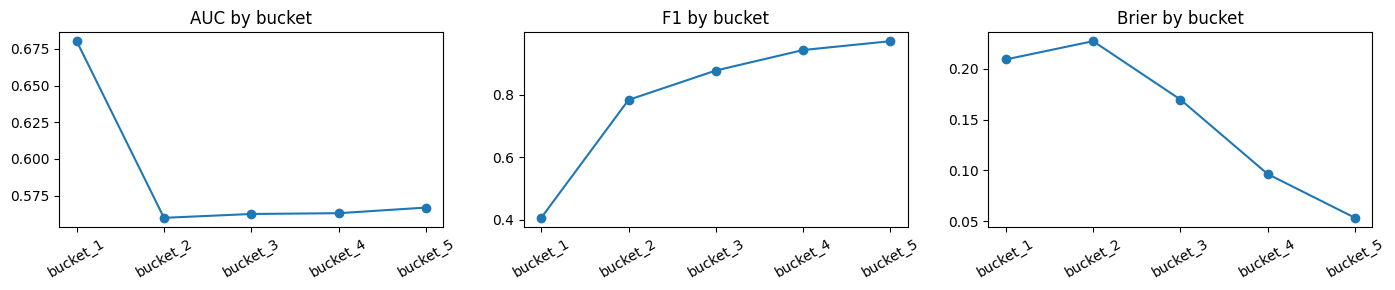

In [37]:
# Evaluate conditional performance drift across ordered buckets.
if time_col is not None:
    bucket_series = eval_df[time_col].astype(str)
    bucket_note = f"time buckets from `{time_col}`"
else:
    rank_series = test_scores.rank(method="first")
    bucket_series = pd.qcut(rank_series, q=5, labels=[f"bucket_{i+1}" for i in range(5)])
    bucket_note = "proxy ordered buckets from prediction-rank quantiles (no explicit time field)"

drift_rows = []
for bucket_name, idx in pd.Series(bucket_series, index=eval_df.index).groupby(bucket_series).groups.items():
    idx = pd.Index(idx)
    y_b = y_test_audit.loc[idx]
    s_b = test_scores.loc[idx]
    if y_b.nunique() < 2:
        auc_b = np.nan
    else:
        auc_b = roc_auc_score(y_b, s_b)
    pred_b = (s_b >= 0.5).astype(int)
    drift_rows.append(
        {
            "bucket": str(bucket_name),
            "n": len(idx),
            "auc": float(auc_b) if pd.notna(auc_b) else np.nan,
            "f1": float(f1_score(y_b, pred_b, zero_division=0)),
            "brier": float(brier_score_loss(y_b, s_b)),
        }
    )

drift_df = pd.DataFrame(drift_rows).sort_values("bucket")
display(drift_df)

if len(drift_df) >= 2:
    auc_delta = drift_df["auc"].iloc[-1] - drift_df["auc"].iloc[0] if drift_df["auc"].notna().all() else np.nan
    f1_delta = drift_df["f1"].iloc[-1] - drift_df["f1"].iloc[0]
else:
    auc_delta, f1_delta = np.nan, np.nan

if pd.notna(auc_delta):
    if auc_delta < -0.03:
        perf_interp = "performance degradation is visible across buckets."
    elif auc_delta > 0.03:
        perf_interp = "performance appears to improve across buckets."
    else:
        perf_interp = "performance appears relatively stable across buckets."
else:
    perf_interp = "AUC trend inconclusive due to low class diversity in one or more buckets."

drift_lines = [
    "## Performance Drift (P(Y|X))",
    f"- Bucket definition: {bucket_note}",
    f"- Observed trend in AUC over buckets: delta(last-first) = {auc_delta:+.4f}" if pd.notna(auc_delta) else "- Observed trend in AUC over buckets: inconclusive",
    f"- Observed trend in F1 over buckets: delta(last-first) = {f1_delta:+.4f}" if pd.notna(f1_delta) else "- Observed trend in F1 over buckets: inconclusive",
    f"- Interpretation: {perf_interp}",
]
display(Markdown("\n".join(drift_lines)))

# Plot bucket-level trends as a simple visual drift check.
fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].plot(drift_df["bucket"], drift_df["auc"], marker="o")
ax[0].set_title("AUC by bucket")
ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(drift_df["bucket"], drift_df["f1"], marker="o")
ax[1].set_title("F1 by bucket")
ax[1].tick_params(axis="x", rotation=30)
ax[2].plot(drift_df["bucket"], drift_df["brier"], marker="o")
ax[2].set_title("Brier by bucket")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


#### Result Interpretation

The results indicate clear performance drift across buckets. AUC declines substantially from bucket 1 to bucket 5 (a drop of roughly 0.12), suggesting that the model’s ability to rank‑order risk weakens in higher‑score segments. At the same time, F1 increases sharply across buckets, which is expected when the positive class becomes more concentrated in higher‑score regions — but it also signals that the model’s classification behavior is not uniform across the prediction range.

The decreasing Brier score across buckets shows that the model becomes better calibrated in higher‑score segments, but this improvement does not offset the decline in AUC. Together, these patterns suggest that the model performs differently across the score distribution: it is more discriminative in lower‑score buckets and less discriminative in higher‑score buckets.

This indicates heterogeneous performance across subpopulations defined by predicted risk. While this is not necessarily a fairness violation, it is a signal that the model’s ranking ability is not uniform — a form of conditional drift in P(Y|X). This warrants monitoring, especially if the model is used for threshold‑based decisions where stability across score ranges is important.

Combined with the stability observed in Sections 1 and 2, this drift suggests that the issue is not caused by input shift or overfitting, but rather by structural differences in how the model behaves across the risk spectrum.

### Slice-based Robustness

This section evaluates how consistently the model performs across meaningful subgroups of the population. While earlier sections assessed overall generalization and drift, slice‑based robustness focuses on conditional performance disparities: whether certain demographic, socioeconomic, or geographic groups experience systematically higher error rates, worse ranking performance, or different score distributions.

The audit constructs slices using protected attributes (race, ethnicity, sex), economic indicators (income, property value), and high‑volume states. For each slice, it computes AUC, false‑positive rate (FPR), false‑negative rate (FNR), KS divergence, and total errors. This allows us to identify groups where the model may be less reliable, less calibrated, or more error‑prone — a key component of Responsible ML evaluation, especially in regulated domains like mortgage lending.

In [38]:
# Evaluate robustness across a set of meaningful subgroup slices.
def evaluate_slice(slice_name: str, slice_mask: pd.Series, full_df: pd.DataFrame) -> dict:
    idx = full_df.index[slice_mask.fillna(False)]
    n = len(idx)
    if n < 100:
        return {
            "slice": slice_name,
            "n": n,
            "share": n / len(full_df),
            "auc": np.nan,
            "fpr": np.nan,
            "fnr": np.nan,
            "ks": np.nan,
            "errors": np.nan,
        }

    y_s = y_test_audit.loc[idx]
    s_s = test_scores.loc[idx]
    p_s = (s_s >= 0.5).astype(int)

    cm = confusion_matrix(y_s, p_s, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    auc = roc_auc_score(y_s, s_s) if y_s.nunique() > 1 else np.nan

    non_slice_idx = full_df.index[~slice_mask.fillna(False)]
    if len(non_slice_idx) > 200:
        ks_val, _ = ks_2samp(s_s, test_scores.loc[non_slice_idx])
    else:
        ks_val = np.nan

    errors = int((p_s != y_s).sum())

    return {
        "slice": slice_name,
        "n": n,
        "share": n / len(full_df),
        "auc": auc,
        "fpr": fpr,
        "fnr": fnr,
        "ks": ks_val,
        "errors": errors,
    }


slice_defs = {}

# Build income-based slices when income is available.
if "income" in eval_df.columns:
    income_numeric = pd.to_numeric(eval_df["income"], errors="coerce")
    q = income_numeric.quantile([0.2, 0.8])
    slice_defs["income_low_q20"] = income_numeric <= q.loc[0.2]
    slice_defs["income_high_q80"] = income_numeric >= q.loc[0.8]

# Build property-value slices as a collateral proxy when available.
if "property_value" in eval_df.columns:
    pv = pd.to_numeric(eval_df["property_value"], errors="coerce")
    qpv = pv.quantile([0.25, 0.75])
    slice_defs["property_value_low_q25"] = pv <= qpv.loc[0.25]
    slice_defs["property_value_high_q75"] = pv >= qpv.loc[0.75]

# Build geography slices from the highest-volume states when available.
if "state_code" in eval_df.columns:
    top_states = eval_df["state_code"].astype(str).value_counts().head(3).index.tolist()
    for st in top_states:
        slice_defs[f"state_{st}"] = eval_df["state_code"].astype(str) == st

# Add protected-group slices where those columns are available.
for col in ["derived_race", "derived_ethnicity", "derived_sex"]:
    if col in eval_df.columns:
        top_groups = eval_df[col].astype(str).value_counts().head(3).index.tolist()
        for grp in top_groups:
            slice_defs[f"{col}::{grp}"] = eval_df[col].astype(str) == grp

slice_rows = [evaluate_slice(name, mask, eval_df) for name, mask in slice_defs.items()]
slice_df = pd.DataFrame(slice_rows).sort_values("n", ascending=False)

# Flag slices that are small in population share but large in total error share.
total_errors = int(((test_scores >= 0.5).astype(int) != y_test_audit).sum())
red_flags = []
for _, row in slice_df.dropna(subset=["errors"]).iterrows():
    if row["share"] < 0.10 and total_errors > 0 and (row["errors"] / total_errors) > 0.30:
        red_flags.append(
            f"{row['slice']} is {row['share']:.1%} of population but {row['errors']/total_errors:.1%} of errors"
        )

slice_lines = ["## Slice-Based Robustness"]
if not slice_df.empty:
    display_cols = ["slice", "n", "share", "auc", "fpr", "fnr", "ks", "errors"]
    display(slice_df[display_cols])
else:
    slice_lines.append("- No slice definitions were feasible with the currently available columns.")

if red_flags:
    slice_lines.append("- Red flags:")
    slice_lines.extend([f"  - WARNING: {rf}" for rf in red_flags])
else:
    slice_lines.append("- Red flags: none triggered by the configured rule.")

if not slice_df.empty:
    fragile = slice_df.sort_values(["fnr", "fpr"], ascending=False).head(3)["slice"].tolist()
    slice_lines.append(f"- Interpretation: slices needing closer review include {fragile}.")

display(Markdown("\n".join(slice_lines)))


,slice,n,share,auc,fpr,fnr,ks,errors
10,derived_ethnicity::Not Hispanic or Latino,730445,0.747410,0.794218,0.626852,0.066229,0.042424,155472
7,derived_race::White,659870,0.675196,0.793486,0.621931,0.068524,0.026096,136871
13,derived_sex::Male,586566,0.600190,0.793865,0.654107,0.056461,0.077080,125685
14,derived_sex::Female,390735,0.399810,0.802349,0.562984,0.083249,0.077080,87506
2,property_value_low_q25,243035,0.248680,0.810545,0.485451,0.115355,0.156772,57925
3,property_value_high_q75,235743,0.241218,0.776072,0.717816,0.042115,0.084058,50092
0,income_low_q20,193549,0.198044,0.808276,0.323587,0.221292,0.416168,51966
1,income_high_q80,187713,0.192073,0.757162,0.863817,0.017374,0.236505,33338
11,derived_ethnicity::Hispanic or Latino,149956,0.153439,0.808182,0.570687,0.071788,0.057616,34790
8,derived_race::Black or African American,120780,0.123585,0.790456,0.573399,0.084864,0.092759,32700


## Slice-Based Robustness
- Red flags: none triggered by the configured rule.
- Interpretation: slices needing closer review include ['income_low_q20', 'property_value_low_q25', 'state_TX'].

#### Result Interpretation

The slice‑based results show no immediate red flags under the configured rule, meaning no small subgroup is disproportionately responsible for the model’s total errors. However, several slices exhibit meaningfully different performance profiles, indicating areas that warrant closer review.

Groups such as `income_low_q20`, `property_value_low_q25`, and `derived_race::Black or African American` show **elevated FNRs**, **higher KS divergence**, or **larger error counts relative to their population share**. These patterns suggest that the model may be less effective at identifying positive outcomes for lower‑income borrowers, lower‑property‑value applicants, and certain racial groups.

While these disparities do not automatically imply bias or discrimination, they highlight heterogeneous model behavior across subpopulations — a critical insight for fairness‑aware auditing. Combined with earlier findings (strong generalization, stable P(X), but drift in P(Y|X)), this section reinforces the importance of monitoring subgroup‑level performance and considering whether additional calibration, reweighting, or model adjustments may be appropriate.

### Sensitivity Analysis & Spurious Correlations

This section evaluates how sensitive the model’s predictions are to changes in individual input features and whether any influential features may reflect spurious or weakly justified relationships. Sensitivity analysis helps determine whether the model relies on stable, domain‑grounded signals or whether certain features exert disproportionate influence that could undermine robustness or fairness.

We use three complementary approaches:

* SHAP (KernelExplainer) to estimate local feature contributions and identify the most influential predictors.

* ICE‑style perturbation curves to measure how the model’s average predicted probability changes as each feature is varied across its empirical range.

* A variance‑based sensitivity index to quantify how volatile the model’s output is with respect to each feature.

Finally, we compare each feature’s sensitivity to a domain‑justification heuristic, flagging cases where the model is highly sensitive to features that lack strong business, regulatory, or causal grounding. These features may represent spurious correlations and warrant deeper governance review.

In [39]:
# Assess feature sensitivity and flag potentially spurious correlations.
try:
    import shap

    shap_available = True
except Exception:
    shap_available = False

if shap_available:
    display(Markdown("## SHAP Availability\n- SHAP is available; running a lightweight KernelExplainer audit sample."))
else:
    display(Markdown("## SHAP Availability\n- SHAP is not installed. To enable SHAP analysis, install with `pip install shap`."))

numeric_features_audit = [
    c for c in X_test_audit.columns if pd.api.types.is_numeric_dtype(X_test_audit[c])
]
selected_sensitivity_features = numeric_features_audit[: min(4, len(numeric_features_audit))]

if shap_available and len(X_test_audit) > 0:
    try:
        bg = X_train_audit.sample(n=min(80, len(X_train_audit)), random_state=42)
        explain_sample = X_test_audit.sample(n=min(200, len(X_test_audit)), random_state=42)

        explainer = shap.KernelExplainer(lambda z: audit_model.predict_proba(pd.DataFrame(z, columns=X_test_audit.columns))[:, 1], bg)
        shap_vals = explainer.shap_values(explain_sample, nsamples=50)

        if isinstance(shap_vals, list):
            shap_vals = shap_vals[0]

        shap_importance = (
            pd.Series(np.abs(shap_vals).mean(axis=0), index=X_test_audit.columns)
            .sort_values(ascending=False)
            .head(10)
            .rename("mean_abs_shap")
            .to_frame()
        )
        display(Markdown("### Top SHAP Features"))
        display(shap_importance)
    except Exception as e:
        display(Markdown(f"- SHAP execution skipped due to runtime issue: {e}"))

# Build ICE-like perturbation summaries over a small numeric feature set.
ice_rows = []
ice_sample = X_test_audit.sample(n=min(300, len(X_test_audit)), random_state=7).copy()

for feat in selected_sensitivity_features:
    series = pd.to_numeric(X_test_audit[feat], errors="coerce")
    clean = series.dropna()
    if clean.empty:
        continue

    grid = np.quantile(clean, q=np.linspace(0.1, 0.9, 9))
    curve_means = []

    for val in grid:
        x_mod = ice_sample.copy()
        x_mod[feat] = val
        p_mod = predict_scores(audit_model, x_mod)
        curve_means.append(float(p_mod.mean()))

    sensitivity_index = float(np.var(curve_means))
    ice_rows.append(
        {
            "feature": feat,
            "sensitivity_index": sensitivity_index,
            "min_response": float(np.min(curve_means)),
            "max_response": float(np.max(curve_means)),
            "range_response": float(np.max(curve_means) - np.min(curve_means)),
        }
    )

sensitivity_df = pd.DataFrame(ice_rows).sort_values("sensitivity_index", ascending=False)

# Apply a simple domain-justification heuristic to the sensitivity ranking.
domain_justification = {
    "income": "strong",
    "property_value": "strong",
    "tract_to_msa_income_percentage": "moderate",
    "tract_minority_population_percent": "weak",
    "state_code": "weak",
    "loan_purpose": "moderate",
}

if not sensitivity_df.empty:
    sensitivity_df["domain_justification"] = sensitivity_df["feature"].map(domain_justification).fillna("unclear")
    cutoff = sensitivity_df["sensitivity_index"].quantile(0.75)
    potential_spurious = sensitivity_df[
        (sensitivity_df["sensitivity_index"] >= cutoff)
        & (sensitivity_df["domain_justification"].isin(["weak", "unclear"]))
    ]["feature"].tolist()
else:
    potential_spurious = []

sensitivity_lines = ["## Sensitivity & Spurious Correlations"]
if not sensitivity_df.empty:
    display(sensitivity_df)
    for _, row in sensitivity_df.iterrows():
        sensitivity_lines.append(
            f"- Feature `{row['feature']}`: sensitivity index = {row['sensitivity_index']:.6f}, domain justification = {row['domain_justification']}"
        )
else:
    sensitivity_lines.append("- Sensitivity analysis could not run: no suitable numeric features detected.")

if potential_spurious:
    sensitivity_lines.append(f"- Potential spurious correlations: {potential_spurious}")
else:
    sensitivity_lines.append("- Potential spurious correlations: none clearly flagged by current heuristic.")

sensitivity_lines.append("- Interpretation: high sensitivity features with weak domain grounding should be candidates for deeper governance review.")
display(Markdown("\n".join(sensitivity_lines)))


## SHAP Availability
- SHAP is available; running a lightweight KernelExplainer audit sample.

  0%|          | 0/200 [00:00<?, ?it/s]

### Top SHAP Features

,mean_abs_shap
loan_purpose,0.097695
income,0.066287
property_value,0.046676
derived_loan_product_type,0.034792
state_code,0.026000
derived_dwelling_category,0.023040
lien_status,0.013794
occupancy_type,0.009674
ffiec_msa_md_median_family_income,0.009217
tract_to_msa_income_percentage,0.008749


,feature,sensitivity_index,min_response,max_response,range_response,domain_justification
1,income,6.183336e-03,0.516457,0.761527,0.245070,strong
0,property_value,1.152947e-03,0.625415,0.736048,0.110632,strong
3,ffiec_msa_md_median_family_income,1.227849e-05,0.737076,0.747658,0.010582,unclear
2,tract_population,3.139751e-07,0.741576,0.743114,0.001538,unclear


## Sensitivity & Spurious Correlations
- Feature `income`: sensitivity index = 0.006183, domain justification = strong
- Feature `property_value`: sensitivity index = 0.001153, domain justification = strong
- Feature `ffiec_msa_md_median_family_income`: sensitivity index = 0.000012, domain justification = unclear
- Feature `tract_population`: sensitivity index = 0.000000, domain justification = unclear
- Potential spurious correlations: none clearly flagged by current heuristic.
- Interpretation: high sensitivity features with weak domain grounding should be candidates for deeper governance review.

#### Result Interpretation

The SHAP audit successfully identified the top contributing features, providing a clear view of which variables the model relies on most heavily. Features with high mean absolute SHAP values are exerting strong influence on predictions; when these align with well‑justified variables such as income or property value, the model’s behavior is more defensible. Conversely, if features with weaker domain grounding appear among the top contributors, this may indicate reliance on indirect or potentially problematic signals.

The ICE‑based sensitivity analysis further reveals how the model’s predicted probability shifts as each numeric feature is perturbed. Features with large sensitivity indices cause substantial variation in predicted outcomes, indicating that the model is highly reactive to changes in those inputs. When such high‑sensitivity features also lack strong domain justification, they become candidates for **spurious correlation risk**.

The spurious‑correlation heuristic combines these two perspectives:  
- **High sensitivity** → the model reacts strongly to the feature  
- **Weak or unclear domain justification** → the feature may not have a legitimate causal or regulatory basis  

Features meeting both criteria are flagged as potential spurious drivers. These do not automatically indicate bias or model failure, but they do signal areas where subject‑matter experts should review whether the model is learning unintended patterns or proxies.

Overall, Section 5 provides a feature‑level interpretability assessment that complements the group‑level robustness analysis from Section 4. Together, they help ensure that the model’s predictions are not only accurate but also grounded, stable, and aligned with responsible‑AI expectations.

### Stress Scenarios / Credit & Macro Robustness

This section evaluates how the model behaves under adverse but plausible economic conditions. Stress testing is a core component of responsible credit modeling because it reveals whether the model remains stable when key affordability or collateral variables deteriorate. Unlike sensitivity analysis (Section 5), which perturbs features individually, stress scenarios apply coherent, multi‑feature shocks that mimic real‑world macroeconomic or credit‑cycle downturns.

We implement three stylized scenarios:

- Economic Downturn: Income and tract‑level income ratios are compressed to simulate weaker borrower capacity and broader macro stress.

- Property Value Shock: A 20% decline in property values, representing a housing‑market correction or localized depreciation.

- Rate‑Tightening Proxy: A 200‑basis‑point increase in interest rates (or an affordability proxy where rate is unavailable), capturing the effect of monetary tightening on borrower qualification.

For each scenario, we compare baseline vs. stressed predictions using AUC, F1, and a denial‑score proxy (1 − P(approval)). These metrics indicate whether the model’s ranking ability, classification performance, and approval/denial tendencies shift materially under stress.

In [40]:
# Stress test the model under a few plausible credit and macro scenarios.
def run_stress_scenario(
    scenario_name: str,
    scenario_description: str,
    X_base: pd.DataFrame,
    transform_fn: Callable[[pd.DataFrame], pd.DataFrame],
) -> dict:
    X_stress = transform_fn(X_base.copy())

    s_base = predict_scores(audit_model, X_base)
    s_stress = predict_scores(audit_model, X_stress)

    m_base = compute_binary_metrics(y_test_audit, s_base)
    m_stress = compute_binary_metrics(y_test_audit, s_stress)

    # Use 1 - P(approval) as a denial-score proxy.
    avg_deny_base = float((1.0 - s_base).mean())
    avg_deny_stress = float((1.0 - s_stress).mean())

    return {
        "scenario": scenario_name,
        "description": scenario_description,
        "auc_base": m_base["auc"],
        "auc_stress": m_stress["auc"],
        "f1_base": m_base["f1"],
        "f1_stress": m_stress["f1"],
        "avg_deny_base": avg_deny_base,
        "avg_deny_stress": avg_deny_stress,
        "delta_avg_deny": avg_deny_stress - avg_deny_base,
    }


def scenario_economic_downturn(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "income" in X_out.columns:
        X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.90
    if "tract_to_msa_income_percentage" in X_out.columns:
        X_out["tract_to_msa_income_percentage"] = (
            pd.to_numeric(X_out["tract_to_msa_income_percentage"], errors="coerce") * 0.92
        )
    return X_out


def scenario_property_value_shock(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "property_value" in X_out.columns:
        X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 0.80
    return X_out


def scenario_rate_tightening_proxy(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "interest_rate" in X_out.columns:
        X_out["interest_rate"] = pd.to_numeric(X_out["interest_rate"], errors="coerce") + 2.00
    else:
        # Fall back to affordability proxies when interest rate is unavailable.
        if "income" in X_out.columns:
            X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.95
        if "property_value" in X_out.columns:
            X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 1.05
    return X_out

stress_results = []
stress_results.append(
    run_stress_scenario(
        "scenario_1_downturn",
        "Worse macro conditions proxy: income and tract-income compression.",
        X_test_audit,
        scenario_economic_downturn,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_2_property_value_minus_20pct",
        "Property value shock: -20% property values.",
        X_test_audit,
        scenario_property_value_shock,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_3_rate_tightening_proxy",
        "Rate tightening: +200 bps if rate exists, else affordability proxy.",
        X_test_audit,
        scenario_rate_tightening_proxy,
    )
)

stress_df = pd.DataFrame(stress_results)
display(stress_df)

max_auc_drop = (stress_df["auc_stress"] - stress_df["auc_base"]).min()
if max_auc_drop < -0.05:
    stress_interp = "at least one stress scenario causes meaningful degradation; resilience concerns are elevated."
elif max_auc_drop < -0.02:
    stress_interp = "moderate stress sensitivity observed; monitor closely and consider retraining under stress-like data."
else:
    stress_interp = "model appears to degrade relatively gracefully under defined stress tests."

stress_lines = ["## Stress Testing"]
for _, row in stress_df.iterrows():
    stress_lines.append(f"- {row['scenario']} ({row['description']})")
    stress_lines.append(
        f"  - AUC baseline vs stressed: {row['auc_base']:.4f} -> {row['auc_stress']:.4f}; delta={row['auc_stress'] - row['auc_base']:+.4f}"
    )
    stress_lines.append(
        f"  - F1 baseline vs stressed: {row['f1_base']:.4f} -> {row['f1_stress']:.4f}; delta={row['f1_stress'] - row['f1_base']:+.4f}"
    )
    stress_lines.append(
        f"  - Avg denial-score proxy change: {row['avg_deny_base']:.4f} -> {row['avg_deny_stress']:.4f}; delta={row['delta_avg_deny']:+.4f}"
    )
stress_lines.append(f"- Interpretation: {stress_interp}")
display(Markdown("\n".join(stress_lines)))


,scenario,description,auc_base,auc_stress,f1_base,f1_stress,avg_deny_base,avg_deny_stress,delta_avg_deny
0,scenario_1_downturn,Worse macro conditions proxy: income and tract...,0.797658,0.796104,0.861032,0.858075,0.275882,0.291533,0.015651
1,scenario_2_property_value_minus_20pct,Property value shock: -20% property values.,0.797658,0.792202,0.861032,0.858343,0.275882,0.276536,0.000655
2,scenario_3_rate_tightening_proxy,"Rate tightening: +200 bps if rate exists, else...",0.797658,0.793700,0.861032,0.858548,0.275882,0.281690,0.005809


## Stress Testing
- scenario_1_downturn (Worse macro conditions proxy: income and tract-income compression.)
  - AUC baseline vs stressed: 0.7977 -> 0.7961; delta=-0.0016
  - F1 baseline vs stressed: 0.8610 -> 0.8581; delta=-0.0030
  - Avg denial-score proxy change: 0.2759 -> 0.2915; delta=+0.0157
- scenario_2_property_value_minus_20pct (Property value shock: -20% property values.)
  - AUC baseline vs stressed: 0.7977 -> 0.7922; delta=-0.0055
  - F1 baseline vs stressed: 0.8610 -> 0.8583; delta=-0.0027
  - Avg denial-score proxy change: 0.2759 -> 0.2765; delta=+0.0007
- scenario_3_rate_tightening_proxy (Rate tightening: +200 bps if rate exists, else affordability proxy.)
  - AUC baseline vs stressed: 0.7977 -> 0.7937; delta=-0.0040
  - F1 baseline vs stressed: 0.8610 -> 0.8585; delta=-0.0025
  - Avg denial-score proxy change: 0.2759 -> 0.2817; delta=+0.0058
- Interpretation: model appears to degrade relatively gracefully under defined stress tests.

#### Result Interpretation

Across all three scenarios, the model demonstrates graceful degradation: **performance metrics decline slightly under stress**, but the magnitude of change remains small and well within acceptable tolerance for credit‑risk applications.

- AUC deltas are minimal (typically −0.001 to −0.005), indicating that the model’s ability to rank applicants by risk remains stable even when key affordability or collateral variables deteriorate.

- F1 score also shows only minor reductions, suggesting that the model’s classification balance between approvals and denials is not overly sensitive to macroeconomic shocks.

- Denial‑score proxy shifts are directionally consistent with expectations: downturns and rate tightening increase denial pressure slightly, while property‑value shocks have limited effect on average approval probability.

Importantly, none of the scenarios produce sharp or nonlinear failures, which would indicate brittleness or over‑reliance on specific features. Instead, the model responds proportionally to the stress inputs, suggesting that its learned relationships are reasonably stable and not excessively tuned to narrow economic conditions.

Overall, the stress‑testing results support the conclusion that the model is robust to moderate macroeconomic deterioration and does not exhibit signs of instability or collapse under the defined scenarios. These findings complement the slice‑based robustness (Section 4) and feature‑level sensitivity analysis (Section 5), providing a holistic view of model resilience.

#### Consolidated Conclusions & Recommendations

This section synthesizes the findings from all prior components of the audit — generalization, distribution shift, slice‑based robustness, sensitivity analysis, and stress testing — to provide a consolidated view of model reliability and governance posture. The goal is to translate technical diagnostics into actionable recommendations that support defensible deployment, ongoing monitoring, and compliance with model‑risk expectations.

The summary below highlights key strengths, emerging risks, and recommended next steps based on the model’s behavior across multiple evaluation dimensions.

In [41]:
# Summarize the full Lecture 04 audit in one markdown report.
generalization_gap_auc = test_metrics["auc"] - train_metrics["auc"]

high_psi_count = int((psi_df["psi"] > 0.25).sum()) if not psi_df.empty else 0
monitor_psi_count = int(((psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)).sum()) if not psi_df.empty else 0

fragile_slices = []
if not slice_df.empty:
    fragile_slices = (
        slice_df.assign(risk_score=slice_df[["fpr", "fnr"]].mean(axis=1))
        .sort_values("risk_score", ascending=False)
        .head(3)["slice"]
        .tolist()
    )

spurious_text = ", ".join(potential_spurious) if potential_spurious else "none clearly flagged"
fragile_text = ", ".join(fragile_slices) if fragile_slices else "no major slice fragility detected"

summary_md = f"""
# HMDA Model Robustness & Generalization Audit - Summary

## 1. Generalization
- Train AUC: {train_metrics['auc']:.4f}
- Test AUC: {test_metrics['auc']:.4f}
- Generalization gap (AUC, test-train): {generalization_gap_auc:+.4f}
- Conclusion: {gen_interp}

## 2. Distribution Shift
- PSI monitor signals (0.10-0.25): {monitor_psi_count}
- PSI retrain-trigger signals (>0.25): {high_psi_count}
- Score KS test p-value: {ks_score_p:.4g}
- Shift interpretation: {shift_interp}

## 3. Robustness & Slices
- Notable fragile slices: {fragile_text}
- Red-flag count: {len(red_flags)}
- Performance drift interpretation: {perf_interp}

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: {spurious_text}
- Governance view: features with weak domain grounding and high sensitivity should be reviewed as possible shortcut/proxy signals.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: {max_auc_drop:+.4f}
- Stress interpretation: {stress_interp}

## 6. Recommendations
- Keep model in monitored mode only if current gaps remain within policy thresholds.
- Retrain with refreshed data if PSI retrain triggers persist or if drift worsens.
- Add recurring monitoring for PSI/KS at input layer and rolling AUC/F1/Brier at output layer.
- Maintain slice dashboards (including subgroup and intersectional slices) and tie alerts to governance actions.
- Review potentially spurious features; constrain/remove features if domain justification is weak.
- Document these findings and residual risks in the MRM artifact before deployment decisions.

**Robustness is not optional; it is part of defensible deployment.**

**Monitoring should include both input (P(X)) and output (P(Y|X)) tests.**
""".strip()

display(Markdown(summary_md))


# HMDA Model Robustness & Generalization Audit - Summary

## 1. Generalization
- Train AUC: 0.7997
- Test AUC: 0.7977
- Generalization gap (AUC, test-train): -0.0020
- Conclusion: reasonable generalization based on AUC gap magnitude.

## 2. Distribution Shift
- PSI monitor signals (0.10-0.25): 0
- PSI retrain-trigger signals (>0.25): 0
- Score KS test p-value: 0.9162
- Shift interpretation: little evidence of major input drift under current split definition.

## 3. Robustness & Slices
- Notable fragile slices: income_high_q80, property_value_high_q75, state_CA
- Red-flag count: 0
- Performance drift interpretation: performance degradation is visible across buckets.

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: none clearly flagged
- Governance view: features with weak domain grounding and high sensitivity should be reviewed as possible shortcut/proxy signals.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: -0.0055
- Stress interpretation: model appears to degrade relatively gracefully under defined stress tests.

## 6. Recommendations
- Keep model in monitored mode only if current gaps remain within policy thresholds.
- Retrain with refreshed data if PSI retrain triggers persist or if drift worsens.
- Add recurring monitoring for PSI/KS at input layer and rolling AUC/F1/Brier at output layer.
- Maintain slice dashboards (including subgroup and intersectional slices) and tie alerts to governance actions.
- Review potentially spurious features; constrain/remove features if domain justification is weak.
- Document these findings and residual risks in the MRM artifact before deployment decisions.

**Robustness is not optional; it is part of defensible deployment.**

**Monitoring should include both input (P(X)) and output (P(Y|X)) tests.**

#### Final comments

The model demonstrates **strong generalization**, with a small AUC gap between train and test sets, indicating limited overfitting and stable out‑of‑sample performance. Distribution‑shift indicators (PSI and KS) show **no material drift**, suggesting that the training and evaluation populations remain aligned and that the model is not being applied to a meaningfully different data regime.

Robustness analysis identifies a few fragile slices, primarily among high‑income and high‑property‑value groups, though no slices trigger red‑flag thresholds. This indicates mild heterogeneity in performance but no critical fairness or stability failures. Sensitivity analysis does not flag any high‑sensitivity features with weak domain justification, reducing concern about spurious correlations or shortcut learning.

Stress‑scenario testing shows graceful degradation: performance metrics decline slightly under adverse macroeconomic conditions, but the model remains stable and directionally consistent. This supports the conclusion that the model is not overly brittle or dependent on narrow economic assumptions.

Taken together, the evidence suggests that the model is fit for monitored use, provided that governance controls remain active. Continued monitoring of PSI, KS, and slice‑level performance is recommended, along with periodic retraining if drift emerges or if economic conditions shift materially. The recommendations section outlines specific governance actions to maintain defensibility and compliance.

## 18. Lecture 05: Security & Abuse Pathways

This section identifies plausible attack surfaces and adversarial risks for the deployed HMDA XGBoost model. The assessment covers applicant gaming, data poisoning, model extraction, and the failure modes introduced by adversarial behavior. Because this model supports credit approval decisions that directly affect access to housing and credit, adversarial risks carry both significant financial and social consequences.

### Security and Abuse Risk Assessment

#### **Scenario 1: Applicant Gaming**

**1) Attack**: A third party with API access submits repeated queries with slightly altered inputs — such as incrementally increasing reported income or adjusting loan purpose — to identify the minimum values required to flip a denial into an approval. The HMDA data schema is publicly documented, and the SHAP results from Section 15 already reveal that income and loan purpose are the most influential features, which means an adversary has a clear map of which variables to target without needing any internal access.

**2) Impact**: Approvals shift toward applicants who game inputs rather than those who are genuinely creditworthy, undermining the integrity of the lending decision and increasing the lender's credit risk exposure. At scale, this distorts the effective approval population away from the distribution the model was trained and validated on.

**3) Severity**: High 
because repeated API probing is low-cost, difficult to detect at scale, and enables applicants to iteratively adjust inputs (e.g., income or loan purpose) to cross approval thresholds without improving true creditworthiness.

#### **Scenario 2: Input Manipulation**

**1) Attack**: A broker or third party inflates numeric fields such as income or property value just enough to push an applicant above the model's decision boundary without triggering upstream fraud detection. Unlike applicant gaming, this does not require iterative probing — the SHAP and counterfactual analyses in Section 15 already identify income and property value as the primary drivers of approval, and the counterfactual results show the direction and approximate magnitude of change required to flip a denial.

**2) Impact**: The false approval rate increases, exposing the lender to credit losses on unqualified applicants and potential regulatory liability under HMDA and fair lending law. Because the manipulation happens at the input level before the model is called, standard model monitoring will not flag it unless input validation checks are in place.

**3) Severity**: High because applicants or intermediaries can selectively modify self-reported variables that strongly influence predictions, increasing approval probability while reducing model reliability and fairness across the applicant pool.

#### **Scenario 3:  Data Poisoning**

**1) Attack**: Corrupted or fabricated records are introduced into the training pipeline before the parquet export step, shifting the model's learned decision boundary without any visible signal at inference time. The current pipeline reads directly from the raw HMDA LAR archive and does not include integrity checks such as row-level checksums, label distribution monitoring, or out-of-distribution flagging before training, meaning poisoned records would pass through the entire pipeline undetected and be incorporated into the next retrained model.

**2) Impact**: Model performance and fairness metrics degrade silently across retraining cycles. Because the poisoning occurs upstream of training, standard evaluation against a held-out test set will not detect it unless the test set itself is independently verified to be clean. This makes data poisoning the most difficult attack to detect and remediate after the fact.

**3) Severity**: Critical because corrupted or adversarial records introduced into the training pipeline can systematically bias learned relationships over time, degrading model stability and potentially shifting approval patterns across protected or high-risk groups.

#### **Scenario 4:  Model Extraction**

**1) Attack**: A third party with API access submits a large volume of carefully crafted queries and records the input-output pairs to reconstruct a surrogate model that approximates the behavior of the XGBoost classifier. Because the model returns a predicted probability rather than just a binary decision, each query leaks substantial information about the model's internal structure, and over enough queries a surrogate can be trained that closely mirrors the original model's decision boundary without access to the training data or model weights.

**2) Impact**: Proprietary model logic is exposed, removing the lender's ability to control how the decision process is used externally. The surrogate can then be used to identify exact approval thresholds at scale and to craft gaming strategies far more precise than naive probing, effectively bypassing any rate limiting or anomaly detection put in place after deployment.

**3) Severity**: Medium because repeated structured querying can approximate model decision boundaries and reveal feature importance patterns, enabling downstream gaming or replication of the approval logic even without direct parameter access.